1. Importing Necessary Libraries

In [13]:
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os, re, time, json
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Union
import cv2
import tensorflow as tf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report
)

2. Configuration — Paths & Datasets

In [3]:
CSV_PATH    = Path(r"C:\Users\evri\Desktop\Διπλωματικη\Adversarial AI Attack Detection\Adversarial-AI-Attack-Detection\fruit_quality_split_annotations.csv")
IMAGES_ROOT = Path(r"C:\Users\evri\Desktop\Διπλωματικη\Adversarial AI Attack Detection\Adversarial-AI-Attack-Detection")
MODELS_DIR  = Path(r"C:\Users\evri\Desktop\Διπλωματικη\Adversarial AI Attack Detection\Adversarial-AI-Attack-Detection\models")
ANNOTATIONS_DIR = Path(r"C:\Users\evri\Desktop\Διπλωματικη\Adversarial AI Attack Detection\Adversarial-AI-Attack-Detection\fruit_quality_adv_annotations")
REL_ROOT    = Path(r"C:\Users\evri\Desktop\Διπλωματικη\Adversarial AI Attack Detection\Adversarial-AI-Attack-Detection")

ANN_PATH = MODELS_DIR / "fruit_quality_ann.keras"
CNN_PATH = MODELS_DIR / "fruit_quality_cnn.keras"
RNN_PATH = MODELS_DIR / "fruit_quality_rnn.keras"

DATASETS = {
    "clean_test": CSV_PATH,  # clean: filter split='test'
    "Annotations_ANN_fgsm": ANNOTATIONS_DIR / "Annotations_ANN_fgsm.csv",
    "Annotations_ANN_pgd":  ANNOTATIONS_DIR / "Annotations_ANN_pgd.csv",
    "Annotations_CNN_fgsm": ANNOTATIONS_DIR / "Annotations_CNN_fgsm.csv",
    "Annotations_CNN_pgd":  ANNOTATIONS_DIR / "Annotations_CNN_pgd.csv",
    "Annotations_RNN_fgsm":  ANNOTATIONS_DIR / "Annotations_RNN_fgsm.csv",
    "Annotations_RNN_pgd":  ANNOTATIONS_DIR / "Annotations_RNN_pgd.csv",
}

IMG_H, IMG_W, IMG_C = 128, 128, 3

SPLIT_FOR_CLEAN = {"clean_test": "test"}    
BATCH_SIZE   = 512     
NUM_BINS_ECE = 15       

COLOR_SPACE = "BGR"  
BIND_BY_NAME = True   

OUT_DIR = Path("./")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_XLSX = OUT_DIR / "evaluation_fruit_quality_summary.xlsx"

3. Utility Functions: Data Loading, Preprocessing, Metrics, and Input Binding

In [4]:
CLASS_NAMES = ['good','bad','mixed']  

def check_exists(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Path not found: {path}")
    return path

for p in [ANN_PATH, CNN_PATH, RNN_PATH]:
    check_exists(p)

def load_csv_safely(path: Path) -> pd.DataFrame:
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        head = f.read(4096)
    sep = ';' if head.count(';') > head.count(',') else ','
    df = pd.read_csv(path, sep=sep, engine='python')
    df.columns = [c.strip() for c in df.columns]

    rename = {}
    for c in df.columns:
        lc = c.strip().lower()
        if lc in ('imageid', 'image_id '): rename[c] = 'image_id'
        if lc == 'label ': rename[c] = 'label'
    if rename:
        df = df.rename(columns=rename)
    return df

LABEL_MAP_STR = {'good':0, 'bad':1, 'mixed':2}

def normalize_labels(series: pd.Series) -> np.ndarray:
    if series.dtype == object:
        s = series.astype(str).str.strip().str.lower().map(LABEL_MAP_STR)
        if s.isna().any():
            bad = series[s.isna()].unique()[:5]
            raise ValueError(f"Unrecognized labels: {bad}")
        return s.values.astype(int)
    vals = series.astype(int).values
    if vals.min() >= 1 and vals.max() <= 3: return vals - 1
    if vals.min() >= 0 and vals.max() <= 2: return vals
    raise ValueError("Unexpected numeric label range; expected {0,1,2} or {1,2,3}.")

def resolve_image_path(rel_or_abs: str) -> Path:
    p = Path(rel_or_abs)
    if p.exists(): return p
    for base in [IMAGES_ROOT, REL_ROOT]:
        cand = base / p
        if cand.exists(): return cand
        cand2 = base / Path(str(p).replace('\\\\','/'))
        if cand2.exists(): return cand2
    raise FileNotFoundError(f"Cannot resolve image path: {rel_or_abs}")

def read_image_tensor(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None: raise OSError(f"Failed to read image: {path}")
    if COLOR_SPACE == "RGB":
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    return img.astype(np.float32) / 255.0

def ece_top1(probs: np.ndarray, y_true: np.ndarray, n_bins: int = 15) -> float:
    conf = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    correct = (preds == y_true).astype(np.float32)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    inds = np.digitize(conf, bins) - 1
    ece = 0.0
    for b in range(n_bins):
        m = inds == b
        if not np.any(m): continue
        ece += (m.mean()) * abs(correct[m].mean() - conf[m].mean())
    return float(ece)

def roc_ovr_metrics(y_true: np.ndarray, probs: np.ndarray) -> Tuple[float,float,float]:
    K = probs.shape[1]
    yb = label_binarize(y_true, classes=list(range(K)))
    aucs, aups, tprs = [], [], []
    for k in range(K):
        yk = yb[:,k]; sk = probs[:,k]
        if yk.sum()==0 or yk.sum()==len(yk): continue
        aucs.append(roc_auc_score(yk, sk))
        from sklearn.metrics import average_precision_score
        aups.append(average_precision_score(yk, sk))
        fpr, tpr, _ = roc_curve(yk, sk); target=0.01
        import numpy as np
        tprs.append(tpr[-1] if fpr[-1] < target else float(np.interp(target, fpr, tpr)))
    return (float(np.mean(aucs)) if aucs else float('nan'),
            float(np.mean(aups)) if aups else float('nan'),
            float(np.mean(tprs)) if tprs else float('nan'))

4. Input Binding Helpers (support ANN, CNN, RNN models)

In [5]:
def get_shape(t):
    try:
        return t.shape.as_list()
    except AttributeError:
        return tuple(t.shape)

def make_row_sequence(images: np.ndarray) -> np.ndarray:
    if images.ndim != 4 or images.shape[-1] != 3:
        raise ValueError(f"Expected images (N,H,W,3), got {images.shape}")
    N, H, W, C = images.shape
    return images.reshape(N, H, W*C)

def build_inputs_by_type(images: np.ndarray, is_night: np.ndarray, model: tf.keras.Model):
    img_tensor = images.astype(np.float32)
    meta_tensor = is_night.reshape(-1,1).astype(np.float32)

    flat_tensor = img_tensor.reshape(img_tensor.shape[0], -1)
    flat_plus_meta = np.concatenate([flat_tensor, meta_tensor], axis=1)

    ranks = [len(get_shape(t)) for t in model.inputs]
    need_seq = any(r == 3 for r in ranks)
    seq_tensor = make_row_sequence(img_tensor) if need_seq else None

    if BIND_BY_NAME:
        feed = {}
        for t in model.inputs:
            name  = t.name.split(':')[0]
            shape = get_shape(t)
            rank  = len(shape)

            if rank == 4:
                feed[name] = img_tensor
            elif rank == 3:
                feed[name] = seq_tensor
            elif rank == 2:
                if shape[-1] in (1, None):
                    feed[name] = meta_tensor
                else:
                    feed[name] = flat_plus_meta
            else:
                feed[name] = img_tensor
        return feed
    else:
        feeds = []
        for t in model.inputs:
            shape = get_shape(t)
            rank  = len(shape)
            if rank == 4:
                feeds.append(img_tensor)
            elif rank == 3:
                feeds.append(seq_tensor)
            elif rank == 2:
                if shape[-1] in (1, None):
                    feeds.append(meta_tensor)
                else:
                    feeds.append(flat_plus_meta)
            else:
                feeds.append(img_tensor)
        return feeds

def per_class_confusion(cm: np.ndarray) -> pd.DataFrame:
    K = cm.shape[0]
    total = cm.sum()
    rows = []
    for k in range(K):
        TP = cm[k,k]
        FN = cm[k,:].sum() - TP
        FP = cm[:,k].sum() - TP
        TN = total - (TP + FP + FN)
        rows.append({'class_id': k, 'class_name': CLASS_NAMES[k],
                     'TP': int(TP), 'FP': int(FP), 'FN': int(FN), 'TN': int(TN)})
    return pd.DataFrame(rows)

5. Dataset Builders: Clean (by split) and Adversarial

In [6]:
def build_clean(df_path: Path, split: str) -> pd.DataFrame:
    df = load_csv_safely(df_path)
    if 'split' not in df.columns:
        raise ValueError("Clean CSV missing 'split' column")
    
    out = df[df['split'].astype(str).str.lower()==split.lower()].copy()

    if 'isNight' not in out.columns:
        out['isNight'] = 0

    if out.empty:
        raise ValueError(f"No rows for split={split}")
    return out

def build_adv(df_path: Path, enforce_test: bool = True) -> pd.DataFrame:
    df = load_csv_safely(df_path)
    if 'image_id' not in df.columns or 'label' not in df.columns:
        raise ValueError(f"Adversarial CSV missing columns: {df_path}")
    
    if enforce_test and 'split' in df.columns:
        df = df[df['split'].astype(str).str.lower() == 'test'].copy()
        if df.empty:
            raise ValueError(f"{df_path.name}: no rows with split='test'")

    if 'isNight' not in df.columns:
        df['isNight'] = 0

    return df

def get_dataset_df(name: str) -> pd.DataFrame:
    src = DATASETS[name]
    if name in SPLIT_FOR_CLEAN:
        return build_clean(src, split=SPLIT_FOR_CLEAN[name])
    return build_adv(src, enforce_test=True)

6. Load Models & Prepare State

In [7]:
MODELS = {
    'ANN': tf.keras.models.load_model(ANN_PATH, compile=False),
    'CNN': tf.keras.models.load_model(CNN_PATH, compile=False),
    'RNN': tf.keras.models.load_model(RNN_PATH, compile=False),
}

print({k:[t.name for t in v.inputs] for k,v in MODELS.items()})

ACCUM_SUMMARIES = []    
ACCUM_TPFP = []         
ACCUM_CMS = []         

{'ANN': ['input_layer_1'], 'CNN': ['image', 'isNight'], 'RNN': ['row_sequence', 'isNight']}


7. valuation Function: Run Model on Dataset and Collect Metrics

In [8]:
def evaluate_one(model_key: str, dataset_key: str):
    model = MODELS[model_key]
    df = get_dataset_df(dataset_key)

    if 'split' in df.columns:
        unique_splits = sorted(df['split'].astype(str).str.lower().unique().tolist())
        if unique_splits != ['test']:
            raise ValueError(f"{dataset_key}: expected only 'test' split, found {unique_splits}")
        
    paths = [resolve_image_path(p) for p in df['image_id'].astype(str).tolist()]
    y_true = normalize_labels(df['label'])
    isN    = df['isNight'].astype(int).values

    probs_all, preds_all = [], []
    idxs = np.arange(len(paths))
    t0 = time.time()

    for s in range(0, len(idxs), BATCH_SIZE):
        part = idxs[s:s+BATCH_SIZE]
        imgs = np.stack([read_image_tensor(paths[i]) for i in part], axis=0)
        meta = isN[part]

        X = build_inputs_by_type(imgs, meta, model)

        logits = model(X, training=False)
        if isinstance(logits,(list,tuple)): logits = logits[0]

        probs = tf.nn.softmax(logits, axis=-1).numpy()
        preds = probs.argmax(axis=1)

        probs_all.append(probs); 
        preds_all.append(preds)

    elapsed = time.time() - t0

    probs_all = np.concatenate(probs_all, axis=0)
    preds_all = np.concatenate(preds_all, axis=0)

    cm = confusion_matrix(y_true, preds_all, labels=[0,1,2])

    cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
    cm_long = cm_df.reset_index().melt(id_vars='index', var_name='pred', value_name='count')
    cm_long = cm_long.rename(columns={'index': 'true'})
    cm_long.insert(0, 'dataset', dataset_key)
    cm_long.insert(0, 'model', model_key)
    ACCUM_CMS.append(cm_long)

    print(f"\n=== {model_key} @ {dataset_key} ===")
    print("Confusion matrix (rows=True, cols=Pred):")
    print(pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES))

    print("\nClassification report:")
    print(classification_report(y_true, preds_all, target_names=CLASS_NAMES, digits=4))

    tpfp = per_class_confusion(cm)
    print("\nTP/FP/FN/TN per class:")
    print(tpfp)

    acc = accuracy_score(y_true, preds_all)
    prec_macro  = precision_score(y_true, preds_all, average='macro', zero_division=0)
    rec_macro   = recall_score(y_true, preds_all, average='macro', zero_division=0)
    f1_macro    = f1_score(y_true, preds_all, average='macro', zero_division=0)

    prec_weight = precision_score(y_true, preds_all, average='weighted', zero_division=0)
    rec_weight  = recall_score(y_true, preds_all, average='weighted', zero_division=0)
    f1_weight   = f1_score(y_true, preds_all, average='weighted', zero_division=0)

    auroc_macro, auprc_macro, tpr1 = roc_ovr_metrics(y_true, probs_all)
    ece = ece_top1(probs_all, y_true, n_bins=NUM_BINS_ECE)

    ms_per_sample = 1000.0 * elapsed / len(y_true)

    summary = {
        'model': model_key, 'dataset': dataset_key, 'n_samples': int(len(y_true)),
        'acc': acc, 'precision_macro': prec_macro, 'recall_macro': rec_macro, 'f1_macro': f1_macro,
        'precision_weighted': prec_weight, 'recall_weighted': rec_weight, 'f1_weighted': f1_weight,
        'auroc_macro_ovr': auroc_macro, 'auprc_macro_ovr': auprc_macro, 'tpr_at_fpr_0.01_macro_ovr': tpr1,
        'ece_top1': ece, 'ms_per_sample': ms_per_sample,
        'color_space': COLOR_SPACE, 'bind_by_name': BIND_BY_NAME
    }
    
    tpfp_long = tpfp.copy()
    tpfp_long.insert(0, 'dataset', dataset_key)
    tpfp_long.insert(0, 'model', model_key)

    ACCUM_SUMMARIES.append(summary)
    ACCUM_TPFP.append(tpfp_long)

print("Call evaluate_one('CNN','clean_test') etc.")

Call evaluate_one('CNN','clean_test') etc.


8. Export Results to Excel (Summary + Per-class TP/FP/FN/TN)

In [9]:
def save_summary_xlsx(path: Path = None):
    if path is None: path = OUT_XLSX

    if not ACCUM_SUMMARIES:
        print("Nothing to save yet. Run evaluate_one(...) first.")
        return None
    
    df_summary = pd.DataFrame(ACCUM_SUMMARIES)
    df_tpfp = pd.concat(ACCUM_TPFP, ignore_index=True)
    df_cm      = pd.concat(ACCUM_CMS, ignore_index=True) if ACCUM_CMS else pd.DataFrame()

    with pd.ExcelWriter(path, engine='xlsxwriter') as w:
        df_summary.to_excel(w, index=False, sheet_name='Summary')
        df_tpfp.to_excel(w, index=False, sheet_name='TPFPFNTN')
        if not df_cm.empty:
            df_cm.to_excel(w, index=False, sheet_name='Confusions')
            
    print("✓ Saved:", path)
    return path

print("When ready, run: save_summary_xlsx()")

When ready, run: save_summary_xlsx()


9. Sanity Check on Training Data

In [10]:
def sanity_check(model_key: str, n_samples: int = 128):
    model = MODELS[model_key]

    df = get_dataset_df('clean_train')
    if len(df) > n_samples:
        df = df.sample(n_samples, random_state=42)

    paths = [resolve_image_path(p) for p in df['image_id'].astype(str).tolist()]
    y_true = normalize_labels(df['label'])
    isN    = df['isNight'].astype(int).values
    imgs = np.stack([read_image_tensor(p) for p in paths], axis=0)

    X = build_inputs_by_type(imgs, isN, model)

    logits = model(X, training=False)
    if isinstance(logits,(list,tuple)): logits = logits[0]

    probs = tf.nn.softmax(logits, axis=-1).numpy()
    preds = probs.argmax(axis=1)

    acc = accuracy_score(y_true, preds)
    print(f"Sanity on TRAIN ({len(df)} samples) — {model_key}: accuracy = {acc:.4f}")
    return acc

print("Run sanity_check('CNN') / ('ANN') / ('RNN')")

Run sanity_check('CNN') / ('ANN') / ('RNN')


10. Sanity Checks, Clean Evaluations, and Save to Excel

In [11]:
print("Datasets available:", list(DATASETS.keys()))

try:
    sanity_check('ANN')
    sanity_check('CNN')
    sanity_check('RNN')
except Exception as e:
    print("Sanity check error:", e)

try:
    evaluate_one('ANN','clean_test')
    evaluate_one('ANN','Annotations_ANN_fgsm')
    evaluate_one('ANN','Annotations_ANN_pgd')
    evaluate_one('ANN','Annotations_CNN_fgsm')
    evaluate_one('ANN','Annotations_CNN_pgd')
    evaluate_one('ANN','Annotations_RNN_fgsm')
    evaluate_one('ANN','Annotations_RNN_pgd')

    evaluate_one('CNN','clean_test')
    evaluate_one('CNN','Annotations_ANN_fgsm')
    evaluate_one('CNN','Annotations_ANN_pgd')
    evaluate_one('CNN','Annotations_CNN_fgsm')
    evaluate_one('CNN','Annotations_CNN_pgd')
    evaluate_one('CNN','Annotations_RNN_fgsm')
    evaluate_one('CNN','Annotations_RNN_pgd')
 
    evaluate_one('RNN','clean_test')
    evaluate_one('RNN','Annotations_ANN_fgsm')
    evaluate_one('RNN','Annotations_ANN_pgd')
    evaluate_one('RNN','Annotations_CNN_fgsm')
    evaluate_one('RNN','Annotations_CNN_pgd')
    evaluate_one('RNN','Annotations_RNN_fgsm')
    evaluate_one('RNN','Annotations_RNN_pgd')

except Exception as e:
    print("Evaluation error:", e)

try:
    save_summary_xlsx()
except Exception as e:
    print("Save error:", e)

Datasets available: ['clean_test', 'Annotations_ANN_fgsm', 'Annotations_ANN_pgd', 'Annotations_CNN_fgsm', 'Annotations_CNN_pgd', 'Annotations_RNN_fgsm', 'Annotations_RNN_pgd']
Sanity check error: 'clean_train'


c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(512, 49153))']
  warnings.warn(msg)
c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(417, 49153))']
  warnings.warn(msg)



=== ANN @ clean_test ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good   1076   65     26
bad      46  626      7
mixed    25   17     65

Classification report:
              precision    recall  f1-score   support

        good     0.9381    0.9220    0.9300      1167
         bad     0.8842    0.9219    0.9027       679
       mixed     0.6633    0.6075    0.6341       107

    accuracy                         0.9048      1953
   macro avg     0.8285    0.8171    0.8223      1953
weighted avg     0.9043    0.9048    0.9043      1953


TP/FP/FN/TN per class:
   class_id class_name    TP  FP  FN    TN
0         0       good  1076  71  91   715
1         1        bad   626  82  53  1192
2         2      mixed    65  33  42  1813


c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(512, 49153))']
  warnings.warn(msg)
c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(417, 49153))']
  warnings.warn(msg)



=== ANN @ Annotations_ANN_fgsm ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good     85  912    170
bad     605   44     30
mixed    55   39     13

Classification report:
              precision    recall  f1-score   support

        good     0.1141    0.0728    0.0889      1167
         bad     0.0442    0.0648    0.0526       679
       mixed     0.0610    0.1215    0.0813       107

    accuracy                         0.0727      1953
   macro avg     0.0731    0.0864    0.0742      1953
weighted avg     0.0869    0.0727    0.0759      1953


TP/FP/FN/TN per class:
   class_id class_name  TP   FP    FN    TN
0         0       good  85  660  1082   126
1         1        bad  44  951   635   323
2         2      mixed  13  200    94  1646


...


=== ANN @ Annotations_CNN_pgd ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good   1039   98     30
bad      48  624      7
mixed    24   18     65

Classification report:
              precision    recall  f1-score   support

        good     0.9352    0.8903    0.9122      1167
         bad     0.8432    0.9190    0.8795       679
       mixed     0.6373    0.6075    0.6220       107

    accuracy                         0.8848      1953
   macro avg     0.8052    0.8056    0.8046      1953
weighted avg     0.8869    0.8848    0.8849      1953


TP/FP/FN/TN per class:
   class_id class_name    TP   FP   FN    TN
0         0       good  1039   72  128   714
1         1        bad   624  116   55  1158
2         2      mixed    65   37   42  1809


c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(512, 49153))']
  warnings.warn(msg)
c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(417, 49153))']
  warnings.warn(msg)



=== ANN @ Annotations_RNN_fgsm ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good    786  309     72
bad     481  186     12
mixed    40   22     45

Classification report:
              precision    recall  f1-score   support

        good     0.6014    0.6735    0.6354      1167
         bad     0.3598    0.2739    0.3110       679
       mixed     0.3488    0.4206    0.3814       107

    accuracy                         0.5207      1953
   macro avg     0.4367    0.4560    0.4426      1953
weighted avg     0.5035    0.5207    0.5087      1953


TP/FP/FN/TN per class:
   class_id class_name   TP   FP   FN    TN
0         0       good  786  521  381   265
1         1        bad  186  331  493   943
2         2      mixed   45   84   62  1762


c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(512, 49153))']
  warnings.warn(msg)
c:\Users\evri\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(417, 49153))']
  warnings.warn(msg)



=== ANN @ Annotations_RNN_pgd ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good   1032   98     37
bad      84  587      8
mixed    24   19     64

Classification report:
              precision    recall  f1-score   support

        good     0.9053    0.8843    0.8947      1167
         bad     0.8338    0.8645    0.8489       679
       mixed     0.5872    0.5981    0.5926       107

    accuracy                         0.8618      1953
   macro avg     0.7754    0.7823    0.7787      1953
weighted avg     0.8630    0.8618    0.8622      1953


TP/FP/FN/TN per class:
   class_id class_name    TP   FP   FN    TN
0         0       good  1032  108  135   678
1         1        bad   587  117   92  1157
2         2      mixed    64   45   43  1801

=== CNN @ clean_test ===
Confusion matrix (rows=True, cols=Pred):
       good  bad  mixed
good   1127   17     23
bad      10  640     29
mixed    10    3     94

Classification report:
              precision    recal

In [14]:
OUT_DIR = Path("./fruit_quality_eval_viz")        
OUT_DIR.mkdir(parents=True, exist_ok=True)
FILE_PREFIX = "fruit_quality_eval"                
MAKE_PDF = True                      

__fig_counter = {'i': 0}   
__orig_show = plt.show      
__pdf = {'obj': PdfPages(OUT_DIR / f"evaluation_visual_report_{datetime.now().strftime('%Y%m%d-%H%M%S')}.pdf")} if MAKE_PDF else {'obj': None}

def _save_current_fig():
    fignums = plt.get_fignums()
    if not fignums:
        return
    num = fignums[-1]          
    fig = plt.figure(num)  

    __fig_counter['i'] += 1
    fname = f"{FILE_PREFIX}_{__fig_counter['i']:02d}.png"
    fig.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")

    if __pdf['obj'] is not None:
        __pdf['obj'].savefig(fig)

def _show_and_save(*args, **kwargs):
    _save_current_fig()
    return __orig_show(*args, **kwargs)

plt.show = _show_and_save

def finalize_autosave():

    if __pdf['obj'] is not None:
        try:
            __pdf['obj'].close()
            print("PDF saved.")
        except Exception as e:
            print("⚠ Error while closing PDF:", e)
    print(f"[AutoSave] Saved {__fig_counter['i']} PNG(s)  to:", OUT_DIR)

print(f"[AutoSave] Enabled. PNGs => {OUT_DIR}, PDF => {MAKE_PDF}")

[AutoSave] Enabled. PNGs => fruit_quality_eval_viz, PDF => True


In [19]:
CLASS_NAMES = ['good','bad','mixed']  

DEFAULT_SUMMARY = Path('.') / 'evaluation_fruit_quality_summary.xlsx'
if DEFAULT_SUMMARY.exists():
    SUMMARY_PATH = DEFAULT_SUMMARY
else:
    candidates = list(Path('.').glob('evaluation_fruit_quality_summary.xlsx'))
    SUMMARY_PATH = max(candidates, key=lambda p: p.stat().st_mtime) if candidates else Path(r'C:/Users/evri/Desktop/Διπλωματικη/Adversarial AI Attack Detection/Adversarial-AI-Attack-Detection/fruit_quality_split_annotations.xlsx')

# Short status output for sanity checks 
print('SUMMARY_PATH:', SUMMARY_PATH)
print('CLASS_NAMES:', CLASS_NAMES)

SUMMARY_PATH: evaluation_fruit_quality_summary.xlsx
CLASS_NAMES: ['good', 'bad', 'mixed']


In [20]:
def read_summary_sheets(xlsx_path: Path):
    try:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary', engine='openpyxl')
    except Exception:
        df_summary = pd.read_excel(xlsx_path, sheet_name='Summary')

    try:
        df_tpfp = pd.read_excel(xlsx_path, sheet_name='TPFPFNTN', engine='openpyxl')
    except Exception:
        try:
            df_tpfp = pd.read_excel(xlsx_path, sheet_name='TPFPFNTN')
        except Exception:
            df_tpfp = None

    try:
        df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions', engine='openpyxl')
    except Exception:
        try:
            df_cm = pd.read_excel(xlsx_path, sheet_name='Confusions')
        except Exception:
            df_cm = None

    return df_summary, df_tpfp, df_cm

df_summary, df_tpfp, df_cm = read_summary_sheets(SUMMARY_PATH)

print('Summary head:'); 
display(df_summary.head())

print("TPFPFNTN head:" if df_tpfp is not None else "No 'TPFPFNTN' sheet found.")
display(df_tpfp.head()) if df_tpfp is not None else None

print('Confusions head:' if df_cm is not None else "No 'Confusions' sheet found (optional).")
display(df_cm.head()) if df_cm is not None else None

Summary head:


,model,dataset,n_samples,acc,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,auroc_macro_ovr,auprc_macro_ovr,tpr_at_fpr_0.01_macro_ovr,ece_top1,ms_per_sample,color_space,bind_by_name
0,ANN,clean_test,1953,0.904762,0.828515,0.817148,0.822268,0.904296,0.904762,0.904283,0.972882,0.871845,0.678840,0.362741,15.295714,BGR,True
1,ANN,Annotations_ANN_fgsm,1953,0.072709,0.073116,0.086378,0.074244,0.086894,0.072709,0.075857,0.262999,0.229590,0.008251,0.482667,25.316924,BGR,True
2,ANN,Annotations_ANN_pgd,1953,0.529954,0.448006,0.498053,0.462252,0.557978,0.529954,0.538892,0.679135,0.429436,0.039150,0.094237,25.433096,BGR,True
3,ANN,Annotations_CNN_fgsm,1953,0.700461,0.629006,0.648929,0.637141,0.710777,0.700461,0.703593,0.860104,0.706031,0.323539,0.176010,29.864409,BGR,True
4,ANN,Annotations_CNN_pgd,1953,0.884793,0.805231,0.805597,0.804569,0.886902,0.884793,0.884932,0.964345,0.857472,0.607771,0.347344,28.724902,BGR,True


TPFPFNTN head:


,model,dataset,class_id,class_name,TP,FP,FN,TN
0,ANN,clean_test,0,good,1076,71,91,715
1,ANN,clean_test,1,bad,626,82,53,1192
2,ANN,clean_test,2,mixed,65,33,42,1813
3,ANN,Annotations_ANN_fgsm,0,good,85,660,1082,126
4,ANN,Annotations_ANN_fgsm,1,bad,44,951,635,323


Confusions head:


,model,dataset,true,pred,count
0,ANN,clean_test,good,good,1076
1,ANN,clean_test,bad,good,46
2,ANN,clean_test,mixed,good,25
3,ANN,clean_test,good,bad,65
4,ANN,clean_test,bad,bad,626


In [21]:
pv_acc = df_summary.pivot(index='model', columns='dataset', values='acc').sort_index()
display(pv_acc.style.format('{:.4f}').set_caption('Accuracy by Model × Dataset'))

pv_f1 = df_summary.pivot(index='model', columns='dataset', values='f1_macro').sort_index()
display(pv_f1.style.format('{:.4f}').set_caption('Macro F1 by Model × Dataset'))

pv_ece = df_summary.pivot(index='model', columns='dataset', values='ece_top1').sort_index()
display(pv_ece.style.format('{:.4f}').set_caption('ECE (Top-1) by Model × Dataset'))

dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.0727,0.5300,0.7005,0.8848,0.5207,0.8618,0.9048
CNN,0.4076,0.8914,0.2919,0.6022,0.5617,0.8996,0.9529
RNN,0.3395,0.8807,0.7778,0.9386,0.1920,0.5315,0.9483


dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.0742,0.4623,0.6371,0.8046,0.4426,0.7787,0.8223
CNN,0.3852,0.8368,0.2860,0.5426,0.4793,0.8405,0.8910
RNN,0.2967,0.8154,0.7431,0.8739,0.1425,0.4455,0.8805


dataset,Annotations_ANN_fgsm,Annotations_ANN_pgd,Annotations_CNN_fgsm,Annotations_CNN_pgd,Annotations_RNN_fgsm,Annotations_RNN_pgd,clean_test
model,,,,,,,
ANN,0.4827,0.0942,0.1760,0.3473,0.0350,0.3349,0.3627
CNN,0.1681,0.3485,0.2483,0.1887,0.0335,0.3531,0.3954
RNN,0.1997,0.3384,0.2325,0.3823,0.3306,0.1136,0.3898


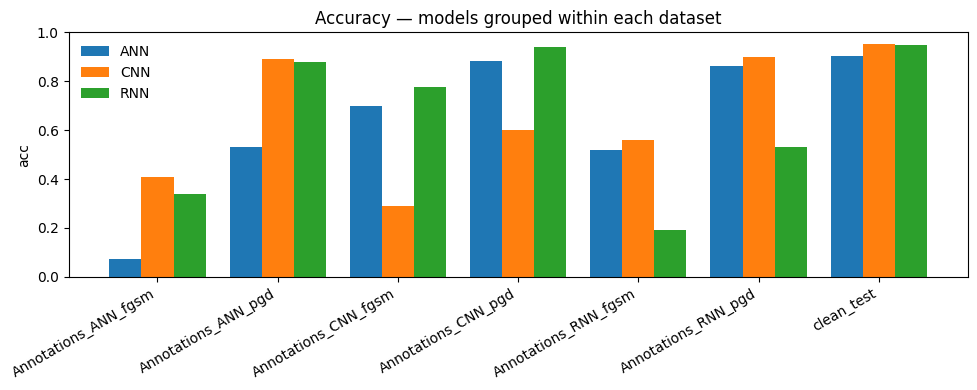

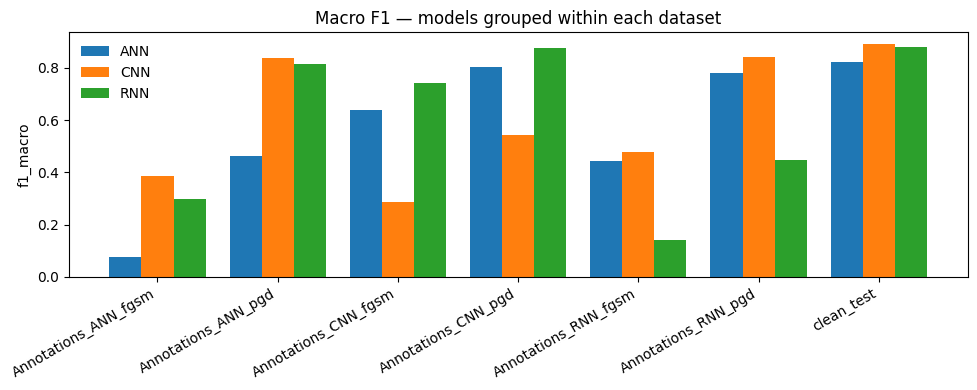

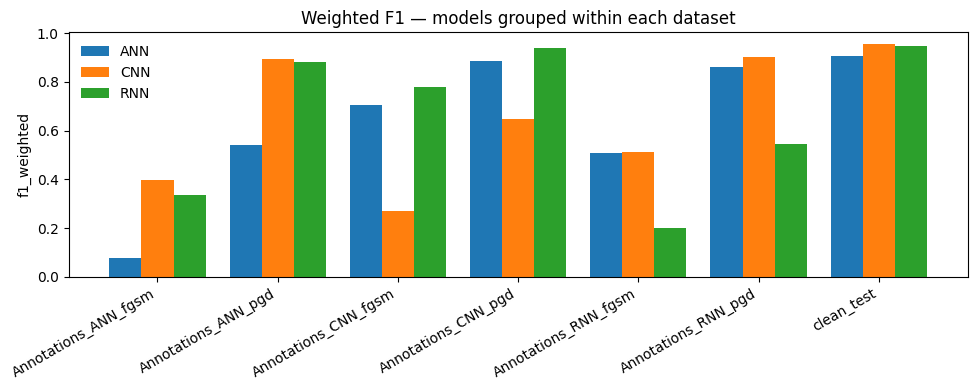

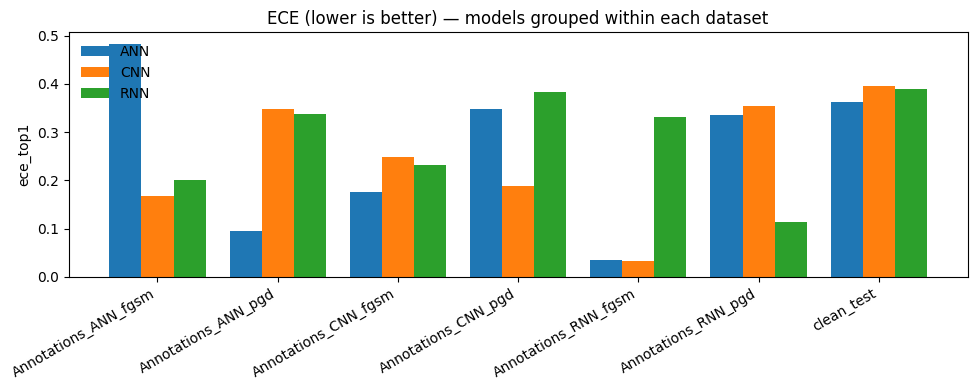

In [ ]:
def grouped_bars(metric_col: str, title: str):
    df = df_summary.copy(); models = sorted(df['model'].unique()); datasets = sorted(df['dataset'].unique())
    width = 0.8 / max(len(models), 1); x = np.arange(len(datasets))
    plt.figure(figsize=(10,4))
    for i, m in enumerate(models):
        sub = df[df['model']==m].set_index('dataset').reindex(datasets)
        vals = sub[metric_col].values
        plt.bar(x + i*width, vals, width, label=m)
    plt.xticks(x + width*(len(models)-1)/2, datasets, rotation=30, ha='right')
    plt.ylabel(metric_col); plt.title(title); plt.legend(frameon=False); plt.tight_layout(); plt.show()
    
grouped_bars('acc', 'Accuracy — models grouped within each dataset')
grouped_bars('f1_macro', 'Macro F1 — models grouped within each dataset')
grouped_bars('f1_weighted', 'Weighted F1 — models grouped within each dataset')
grouped_bars('ece_top1', 'ECE (lower is better) — models grouped within each dataset')

,model,dataset,class_id,class_name,TP,FP,FN,TN
0,ANN,clean_test,0,good,1076,71,91,715
1,ANN,clean_test,1,bad,626,82,53,1192
2,ANN,clean_test,2,mixed,65,33,42,1813
3,ANN,Annotations_ANN_fgsm,0,good,85,660,1082,126
4,ANN,Annotations_ANN_fgsm,1,bad,44,951,635,323


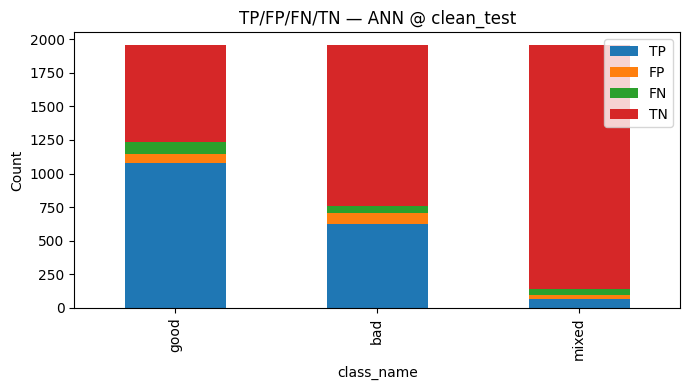

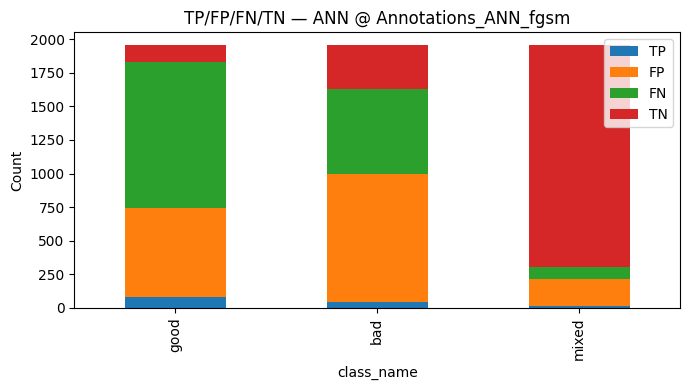

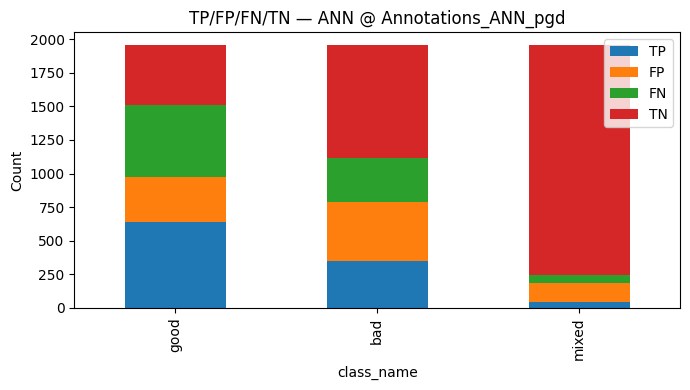

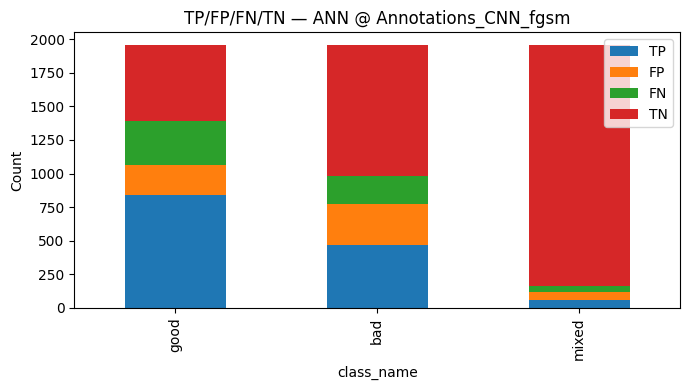

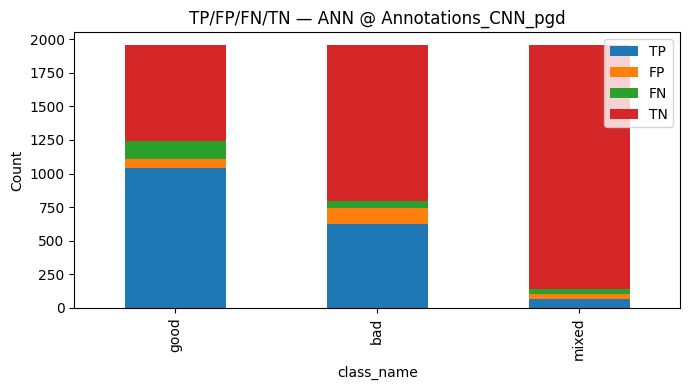

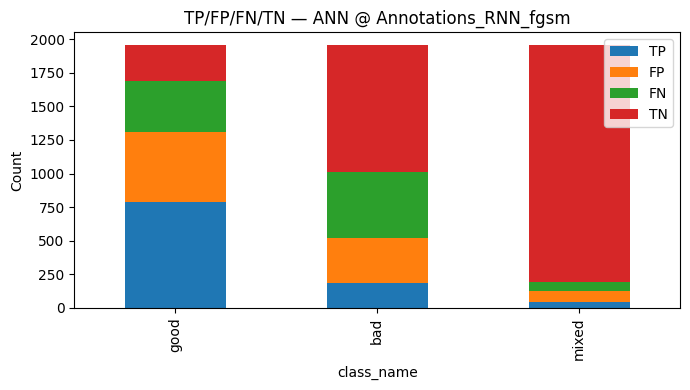

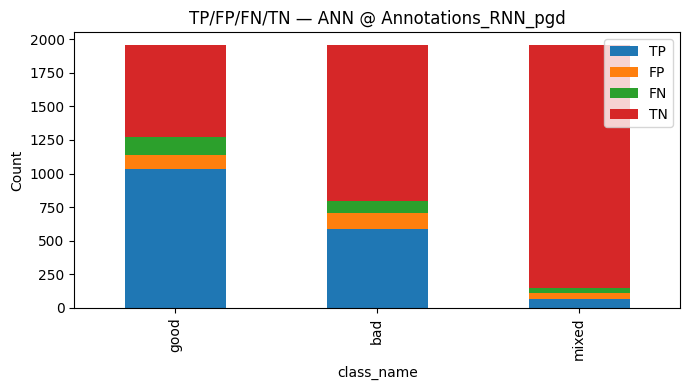

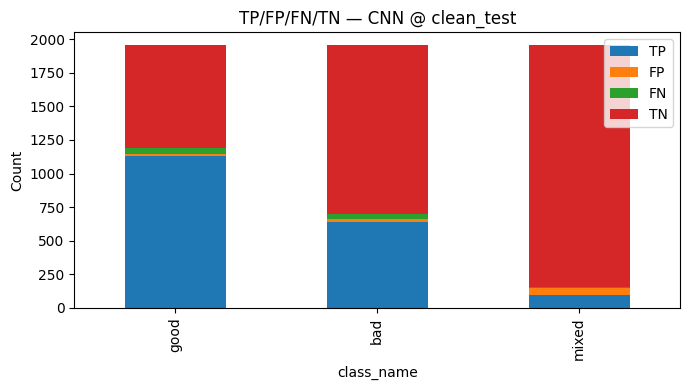

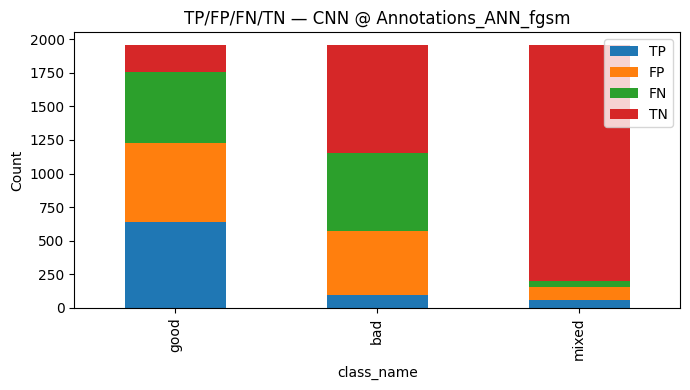

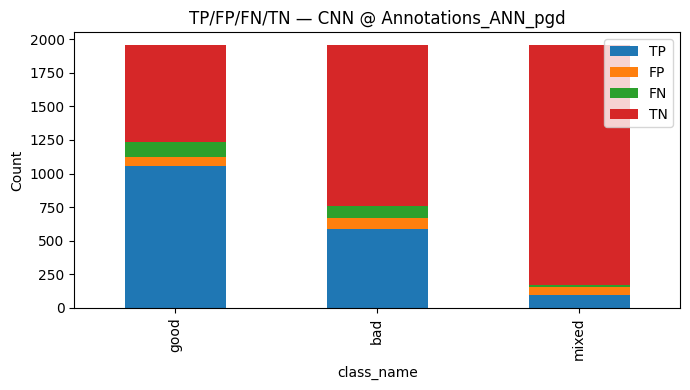

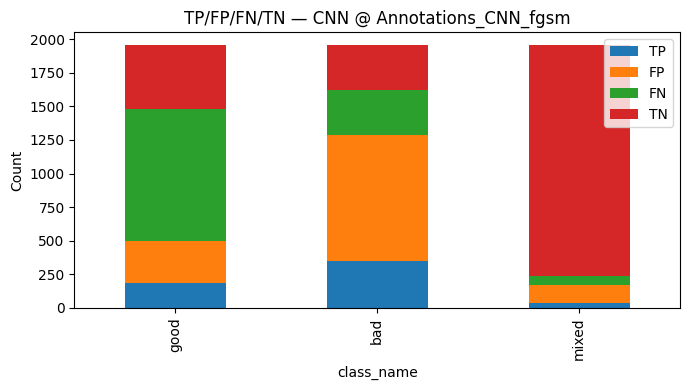

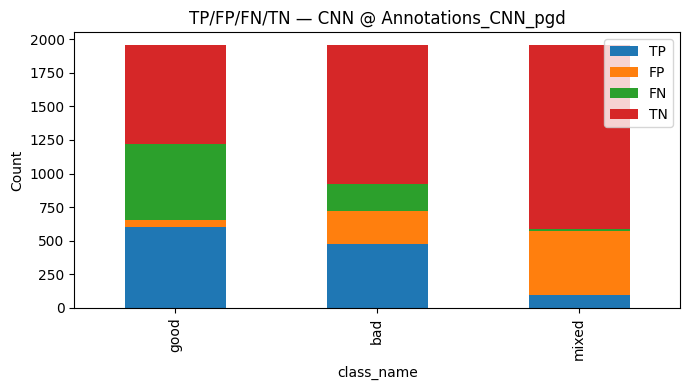

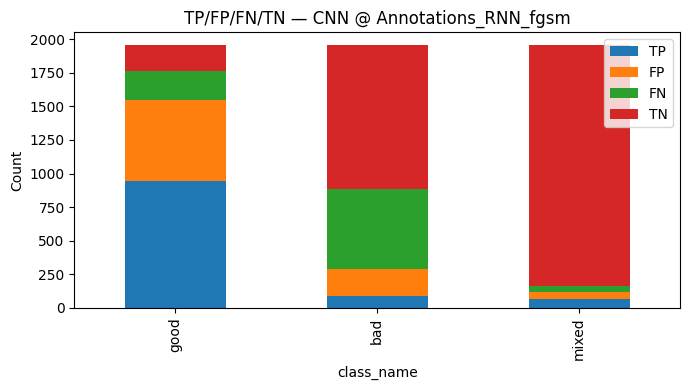

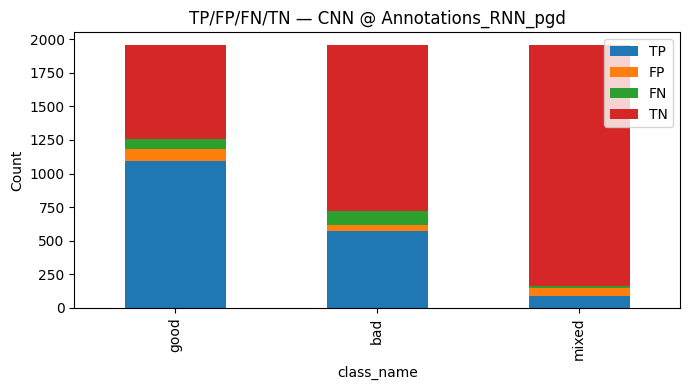

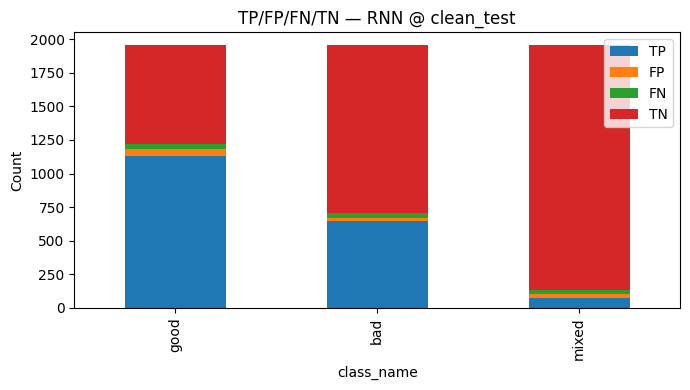

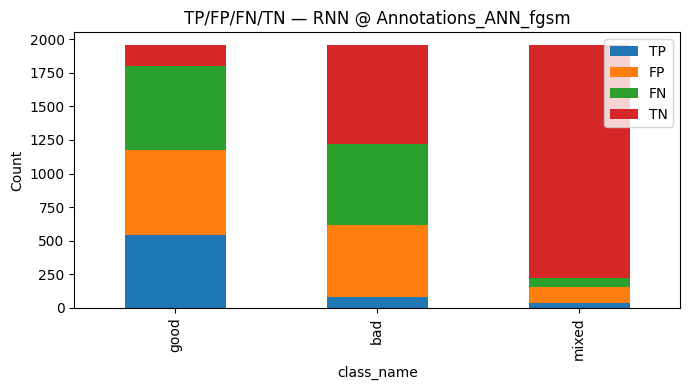

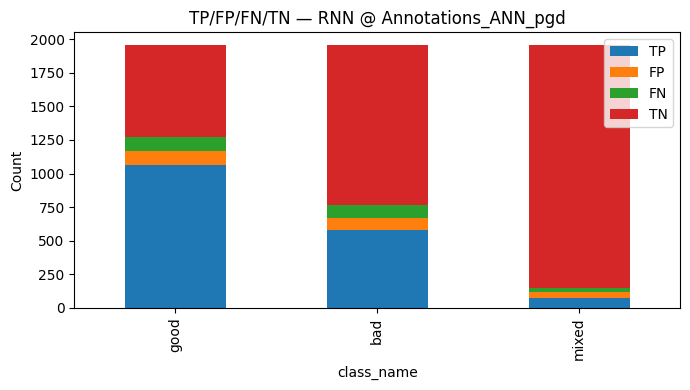

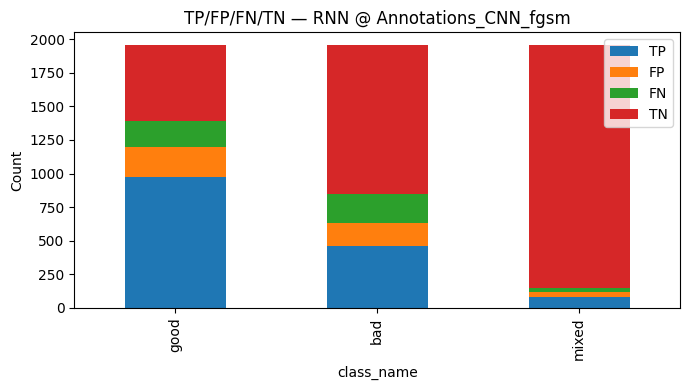

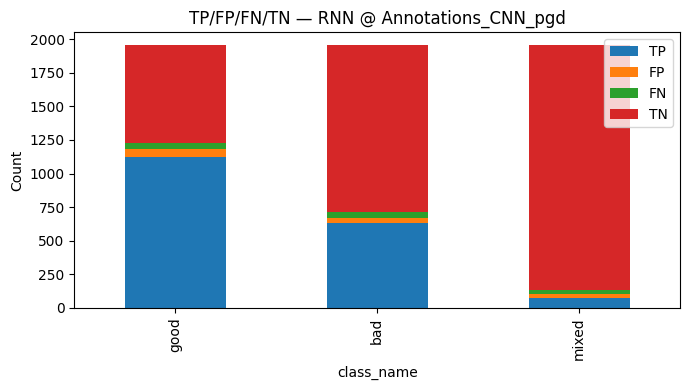

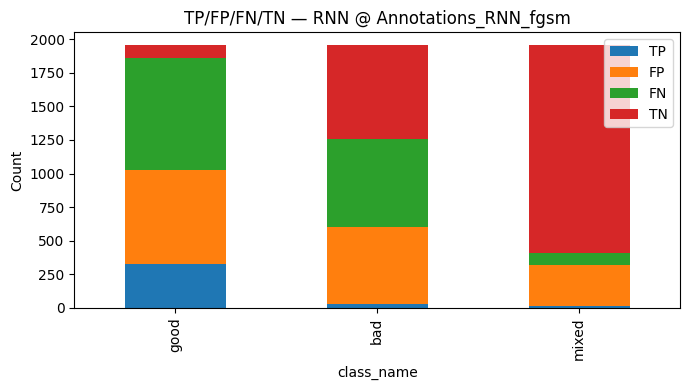

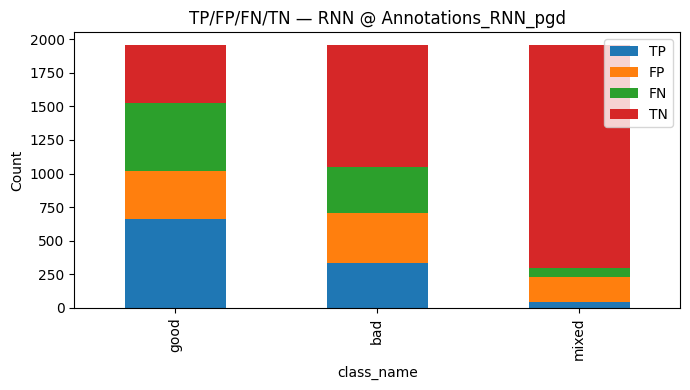

In [ ]:
if df_tpfp is not None and not df_tpfp.empty:
    display(df_tpfp.head())

    def plot_tpfp_for(model: str, dataset: str):
        sub = df_tpfp[(df_tpfp['model']==model) & (df_tpfp['dataset']==dataset)]
        if sub.empty:
            print(f'No TP/FP/FN/TN for {model} @ {dataset}'); return
        sub = sub.set_index('class_name').reindex(CLASS_NAMES)
        counts = sub[['TP','FP','FN','TN']]
        counts.plot(kind='bar', stacked=True, figsize=(7,4), title=f'TP/FP/FN/TN — {model} @ {dataset}')
        plt.ylabel('Count'); plt.tight_layout(); plt.show()
        
    combos = df_tpfp[['model','dataset']].drop_duplicates().values
    for model, dataset in combos:
        plot_tpfp_for(model, dataset)
else:
    print("No TP/FP/FN/TN sheet available. Re-run notebook 12 and save with TPFPFNTN sheet.")

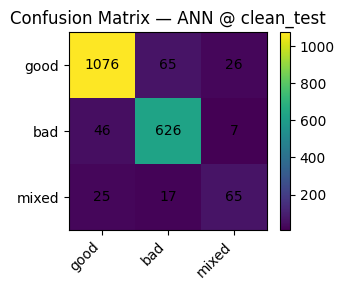

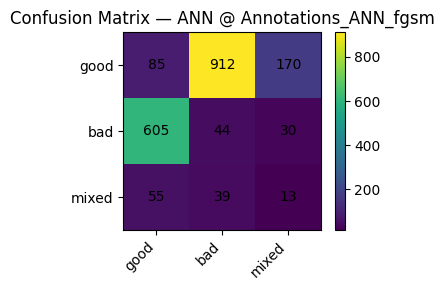

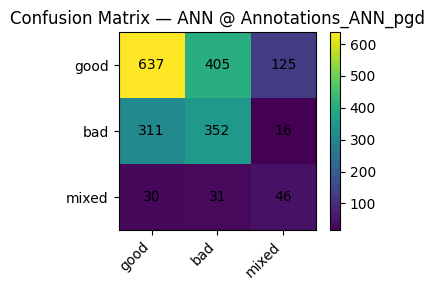

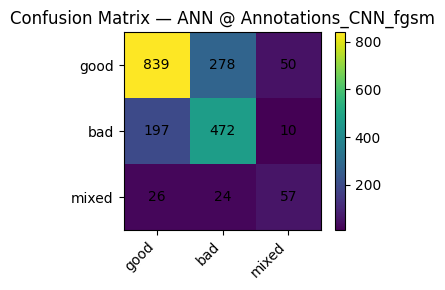

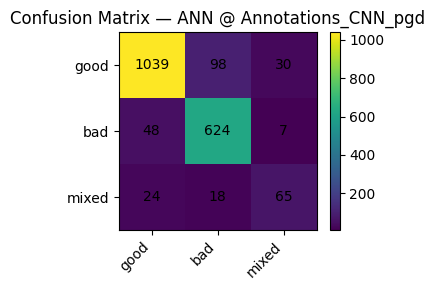

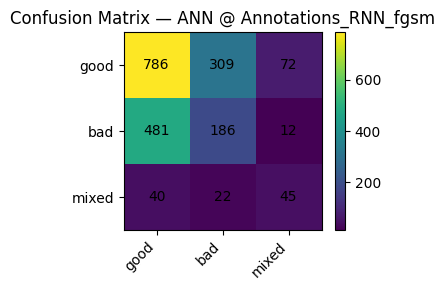

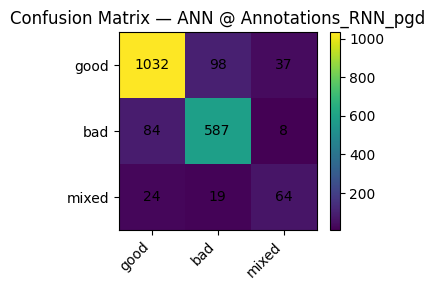

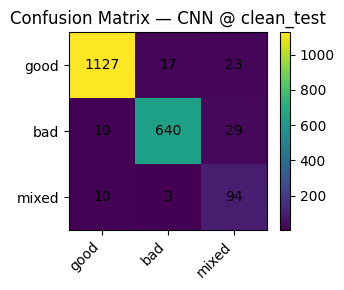

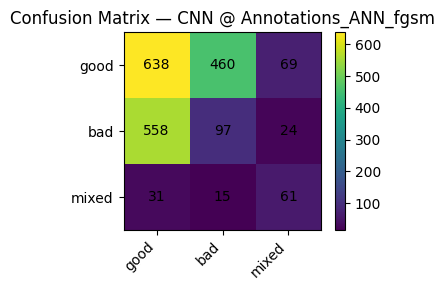

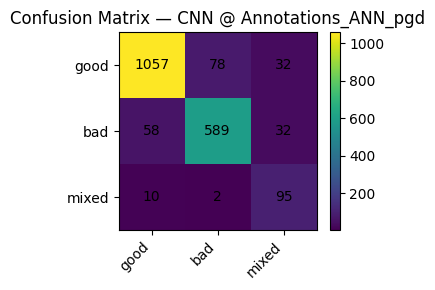

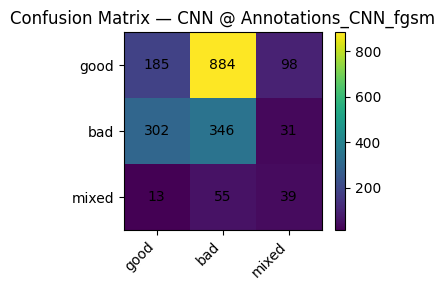

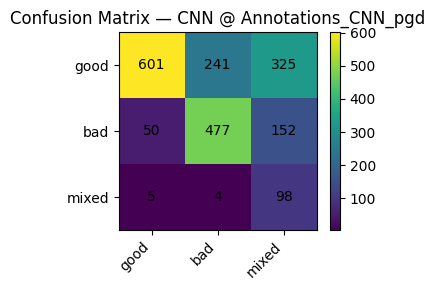

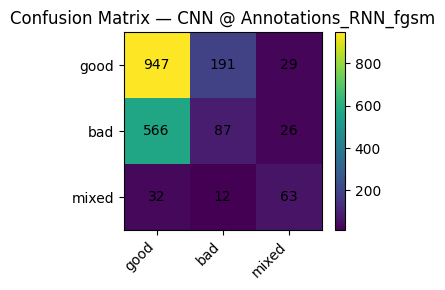

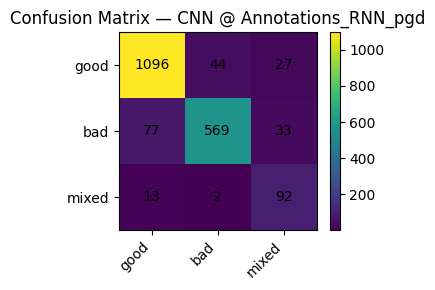

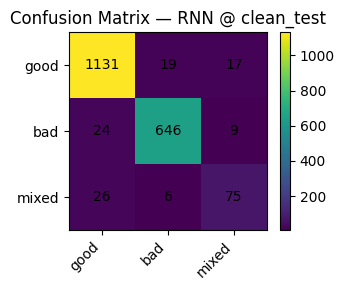

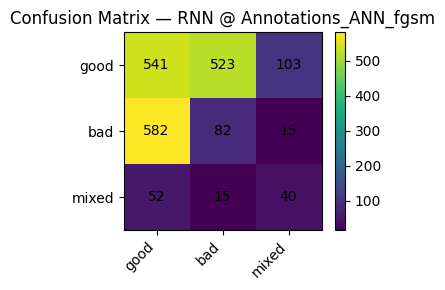

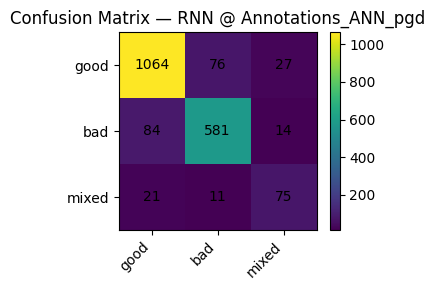

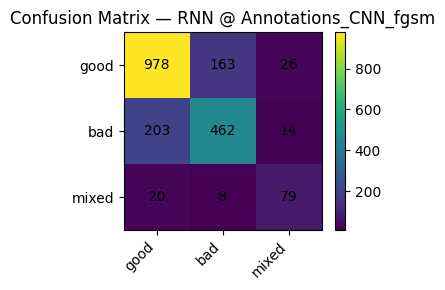

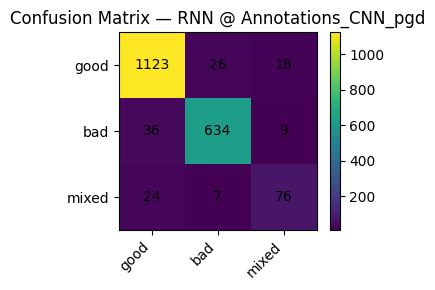

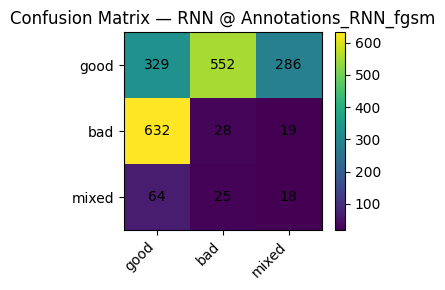

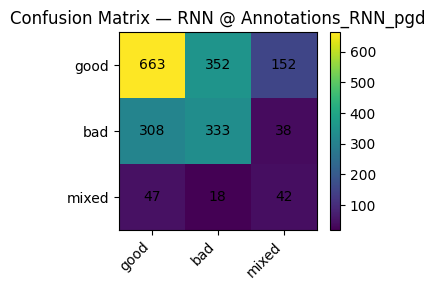

In [24]:
if df_cm is not None and not df_cm.empty:
    combos = df_cm[['model','dataset']].drop_duplicates().values
    for model, dataset in combos:
        sub = df_cm[(df_cm['model']==model) & (df_cm['dataset']==dataset)]
        if sub.empty: continue
        pivot = (sub.pivot(index='true', columns='pred', values='count')
                 .reindex(index=CLASS_NAMES, columns=CLASS_NAMES).fillna(0))
        plt.figure(figsize=(4,3)); plt.title(f'Confusion Matrix — {model} @ {dataset}')
        im = plt.imshow(pivot.values, interpolation='nearest')
        plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45, ha='right')
        plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
        plt.colorbar(im, fraction=0.046, pad=0.04)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                plt.text(j, i, int(pivot.values[i, j]), ha='center', va='center')
        plt.tight_layout(); plt.show()
else:
    print("No 'Confusions' sheet found. (Optional feature)")

In [ ]:
try:
    finalize_autosave()
except NameError:
    print("AutoSave dont run.")

PDF saved.
[AutoSave] Saved 46 PNG(s)  to: fruit_quality_eval_viz
